In [1]:
import numpy as np
import sys
from pathlib import Path
import copy

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)
from theory import TheoryManipulator

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# BAO Multipole Models
### Theoretical exploration of Zel'dovich smearing model
***

# Basic Example

## Setup

### Configuration setup

In [3]:
Sample = 'DESI-LRG2' # one of '','DESI-LRG2' or 'Euclid-ELG'
Model_AP = True      # can be True only if Sample != ''
Include_Sig2Obs = True 
L_Max = 3

Modify_Data = True # default True
Accuracy = 'mid' # 'low','mid' or 'high'. Default 'mid', giving <~3% error on quadrupole

tm = TheoryManipulator(sample=Sample,model_AP=Model_AP,include_Sig2obs=Include_Sig2Obs,L_Max=L_Max,
                       modify_data=Modify_Data,accuracy=Accuracy,base_dir=Base_Dir)


-------------------------------------------
Theory manipulation for Zel'dovich smearing
-------------------------------------------
Setup...
... config
... files and folders
... basis functions (BiSequential instance)
... ... using 9 basis functions: [0,1,2,3,4,5,6,7,8]
... ... loading BiSequential instance
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
... ... extracting basis instance
... extracting basis functions from NNa
... setting up 2

### Files and folders

In [4]:
print('   Plots dir   : ',tm.plots_dir)
print(' Scales file   : ',tm.scales_file)
print('Cov mat file   : ',tm.cov_file)
print('   Data file(s): ',tm.data_file)

   Plots dir   :  ./plots/AbacusSummit/base_c000/DESI-LRG2/
 Scales file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800_scales.txt
Cov mat file   :  ./data/AbacusSummit/base_c000/DESI-LRG2/covmat_LMax3_lgMmin12.90_z0.800_inclSig2obs_AP.txt
   Data file(s):  ['./data/AbacusSummit/base_c000/DESI-LRG2/Sig2obs_LMax3_lgMmin12.90_z0.800.txt', './data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800.txt']


### Fiducial values
( Based on ground truth for cosmology and MCMC analysis for sdbmc )

In [5]:
xilin_true = tm.load_xilin(tm.fiducial['growth'][tm.sample])

print('---------------')
print('Fiducial values')
print('---------------')
for key in tm.fiducial.keys():
    if np.isscalar(tm.fiducial[key]):
        value = tm.fiducial[key]
    else:
        value = tm.fiducial[key][tm.sample]
    print(key+': {0:.3e}'.format(value))
print('---------------')
print('Params list:',tm.params_list)
print('---------------')
print(' Latex list:',tm.latex_list)
print('---------------')

---------------
Fiducial values
---------------
f: 8.389e-01
growth: 6.648e-01
sigv: 3.870e+00
Daiso: 6.910e-04
DaAP: -5.939e-04
fv: 2.600e-01
rLP: 9.304e+01
rZC: 1.206e+02
w_0: 5.925e-03
w_1: -1.205e-02
w_2: -9.072e-03
w_3: 1.600e-02
w_4: 6.265e-03
w_5: 1.796e-02
w_6: -1.719e-02
w_7: 6.749e-03
w_8: 1.829e-02
b: 2.383e+00
B1st: -1.229e+00
Bvst: 8.760e+00
AMC: 2.406e-02
sigma: 7.362e+00
beta: 3.520e-01
qbar2: 5.637e-02
qbar4: 0.000e+00
---------------
Params list: ['beta', 'sigv', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 'b', 'B1st', 'Bvst', 'sigma', 'AMC', 'qbar2', 'qbar4', 'fv', 'Daiso', 'DaAP']
---------------
 Latex list: ['\\beta', '\\sigma_{\\rm v}', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 'b', 'B_{1\\ast}', 'B_{v\\ast}', '\\sigma', 'A_{\\rm MC}', '\\bar q^{(2)}', '\\bar q^{(4)}', 'f_{\\rm v}', '\\Delta\\alpha_{\\rm iso}', '\\Delta\\alpha_{\\rm AP}']
---------------


## Model evaluation

### Evaluation dictionary

In [6]:
Eval_Dict = {}
for key in tm.params_list:
    if np.isscalar(tm.fiducial[key]):
        value = tm.fiducial[key]
    else:
        value = tm.fiducial[key][tm.sample]
    Eval_Dict[key] = value
# Eval_Dict

### Evaluate!

In [7]:
prediction = tm.calc_model(Eval_Dict) # default wrap=True
prediction_flat = tm.calc_model(Eval_Dict,wrap=False)
# print(prediction_flat)

## Data

### Load data

In [8]:
data,cov_data = tm.load_data()
data_flat,cov_data = tm.load_data(wrap=False)
# print(data_flat)

### Compare model

In [9]:
# compare data with model
chi2 = tm.calc_chi2(data_flat,prediction_flat)
print('chi2: {0:.1f}'.format(chi2))

chi2: 187.7


## Plots

### Basic comparison

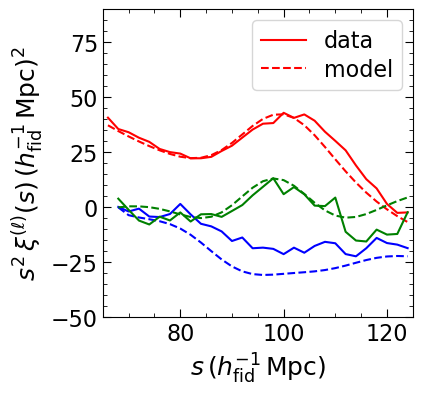

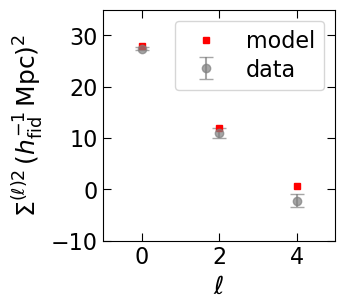

In [10]:
plt.figure(figsize=(4,4))
plt.xlabel("$s\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$")
plt.ylabel("$s^{{2}}\\,\\xi^{{(\\ell)}}(s)\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
plt.xlim(65,125)
if Modify_Data:
    plt.ylim(-50,90)
else:
    plt.ylim(-120,120)
off = 1 if Modify_Data else 0
offset = 1 if Include_Sig2Obs else 0
plt.plot(tm.theory.svals,tm.theory.svals**2*data[offset],'r-',label='data')
plt.plot(tm.theory.svals,tm.theory.svals**2*prediction[offset],'r--',label='model')
if L_Max > 1:
    plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*data[offset+1],'b-')
    plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*prediction[offset+1],'b--')
    if L_Max == 3:
        plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*data[offset+2],'g-')
        plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*prediction[offset+2],'g--')
plt.legend(loc='upper right')
plt.minorticks_on()
plt.show()

if Include_Sig2Obs:
    Sigx = np.array([2*L for L in range(L_Max)])
    plt.figure(figsize=(3,3))
    plt.xlabel("$\\ell$")
    plt.ylabel("$\\Sigma^{{(\\ell)2}} \\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
    plt.xlim(-1,2*L_Max-1)
    plt.ylim(-10,35)
    plt.xticks(Sigx)
    plt.errorbar(Sigx,data[0],yerr=np.sqrt(np.diag(cov_data)[:L_Max]),
                 capsize=5,marker='o',c='gray',ls='none',alpha=0.7,label='data')
    plt.plot(Sigx,prediction[0],'r',marker='s',ls='none',markersize=4,label='model')
    plt.legend(loc='upper right')
    plt.show()

### Basis functions

In [11]:
# for use with basis functions
CMap = plt.cm.plasma
sm = plt.cm.ScalarMappable(cmap=CMap, norm=plt.Normalize(vmin=1, vmax=tm.n_basis))

#### Raw basis $b_m(r)$

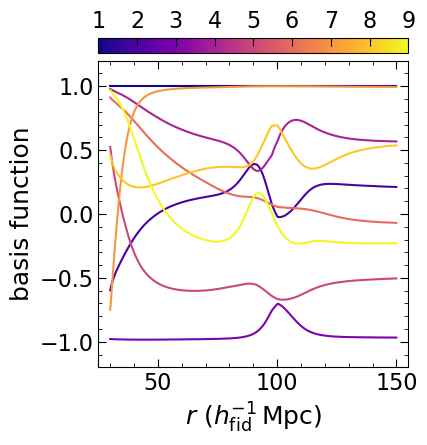

In [12]:
rvals = np.linspace(30,150,500)
basis_func = tm.load_basis_func(rvals)

FSize = 4
fig,ax = plt.subplots(1,1,figsize=(FSize,1.2*FSize))
plt.ylim(-1.2,1.2)
plt.xlim(25,155)
plt.xlabel('$r\\,\\,(h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$')
plt.ylabel('basis function')
cols = iter(CMap(np.linspace(0,1,tm.n_basis)))
for b in range(tm.n_basis):
    col = next(cols)
    plt.plot(rvals,rvals**0*basis_func[b],'-',color=col,lw=1.5)
plt.minorticks_on()

cb = plt.colorbar(sm,ax=ax,orientation='horizontal',location='top',pad=0.02)
cb.set_ticks(np.arange(1,tm.n_basis+1))

plt.show()


#### Smoothed basis $\lambda_m(s), \bar \lambda_m(s), \bar{\bar{\lambda}}_m(s)$

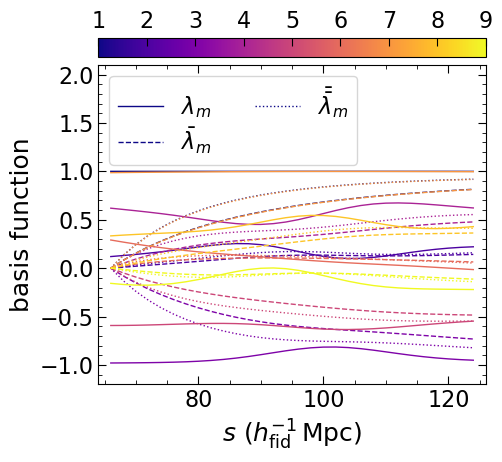

In [13]:
lam = tm.theory.calc_lambda(Eval_Dict['sigma'])
if L_Max > 1:
    lam_b,lam_bb = tm.theory.calc_lambda_bars(Eval_Dict['sigma'])
FSize = 5
fig,ax = plt.subplots(1,1,figsize=(FSize,FSize))
plt.xlim(64,126)
plt.ylim(-1.2,2.1)
plt.xlabel('$s\\,\\,(h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$')
plt.ylabel('basis function')
cols = iter(CMap(np.linspace(0,1,tm.n_basis)))
for b in range(tm.n_basis):
    col = next(cols)
    label = "$\\lambda_{{m}}$" if b==0 else None
    plt.plot(tm.theory.svals,lam[b],lw=1,ls='-',color=col,label=label)
    if L_Max > 1:
        label = "$\\bar{{\\lambda}}_{{m}}$" if b==0 else None
        plt.plot(tm.theory.svals,lam_b[b],lw=1,ls='--',color=col,label=label)
        if L_Max == 3:
            label = "$\\bar{{\\bar{{\\lambda}}}}_{{m}}$" if b==0 else None
            plt.plot(tm.theory.svals,lam_bb[b],lw=1,ls=':',color=col,label=label)
plt.legend(loc='upper left',ncol=2)
plt.minorticks_on()

cb = plt.colorbar(sm,ax=ax,orientation='horizontal',location='top',pad=0.02)
cb.set_ticks(np.arange(1,tm.n_basis+1))
plt.show()

#### Smoothed basis derivatives $\lambda_m^{(n)}(s),\Lambda_m^{(n)}(s)$

Highest order derivative calculated: n = 6


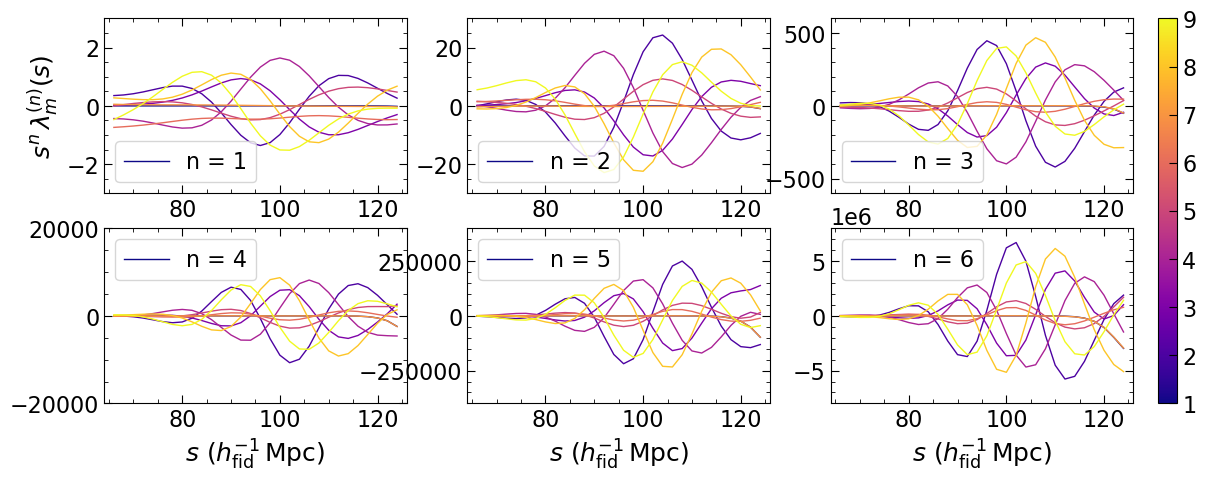

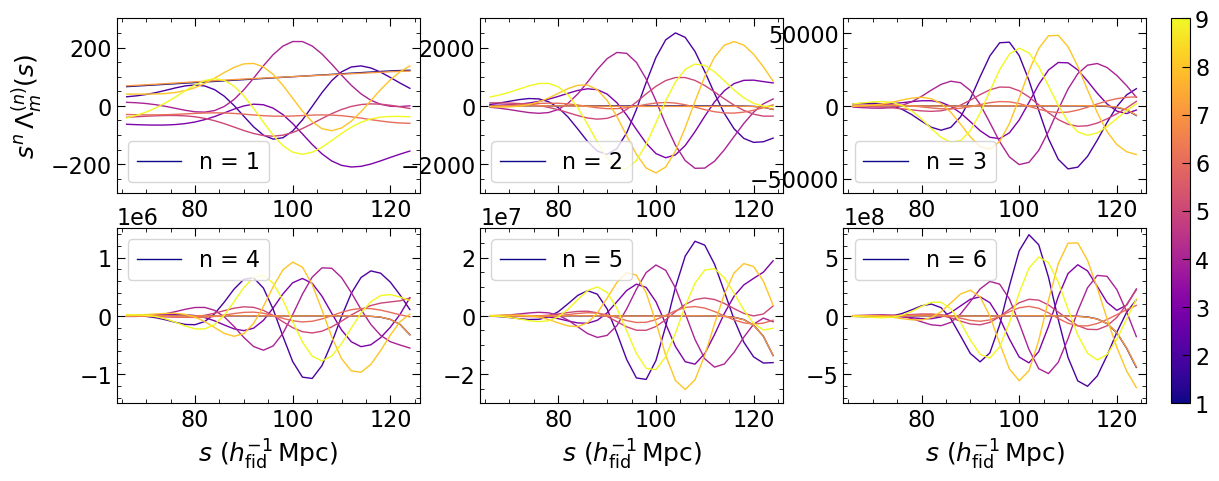

In [14]:
    
print('Highest order derivative calculated: n = {0:d}'.format(tm.theory.max_deriv))

lam_m_n,Lam_m_n = tm.theory.calc_der_lambda(Eval_Dict['sigma'])

FSize = 5
fig,ax = plt.subplots(tm.theory.max_deriv//3,3,figsize=(3.2*FSize,FSize))
Ylim = np.array([[[-3,3],[-30,30],[-600,600]],[[-2e4,2e4],[-4e5,4e5],[-8e6,8e6]]])
for c in range(3):
    for r in range(tm.theory.max_deriv//3):
        n = 3*r+c
        ax[r,c].set_xlim(64,126)
        ax[r,c].set_ylim(Ylim[r,c,0],Ylim[r,c,1])
        if (r==tm.theory.max_deriv//3-1):
            ax[r,c].set_xlabel('$s\\,\\,(h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$')
        if (c==0) & (r==0):
            ax[r,c].set_ylabel('$s^{{n}}\\,\\lambda_{{m}}^{{(n)}}(s)$')
        cols = iter(CMap(np.linspace(0,1,tm.n_basis)))
        for b in range(tm.n_basis):
            col = next(cols)
            label = "n = {0:d}".format(n+1) if b==0 else None
            ax[r,c].plot(tm.theory.svals,tm.theory.svals**(n+1)*lam_m_n[n,b],lw=1,ls='-',color=col,label=label)
        ax[r,c].legend(loc='lower left' if r==0 else 'upper left')
        ax[r,c].minorticks_on()

cb = plt.colorbar(sm,ax=ax,orientation='vertical',location='right',pad=0.02)
cb.set_ticks(np.arange(1,tm.n_basis+1))
plt.show()

FSize = 5
fig,ax = plt.subplots(tm.theory.max_deriv//3,3,figsize=(3.2*FSize,FSize))
Ylim = np.array([[[-3e2,3e2],[-3e3,3e3],[-6e4,6e4]],[[-1.5e6,1.5e6],[-3e7,3e7],[-7.5e8,7.5e8]]])
for c in range(3):
    for r in range(tm.theory.max_deriv//3):
        n = 3*r+c
        ax[r,c].set_xlim(64,126)
        ax[r,c].set_ylim(Ylim[r,c,0],Ylim[r,c,1])
        if (r==tm.theory.max_deriv//3-1):
            ax[r,c].set_xlabel('$s\\,\\,(h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$')
        if (c==0) & (r==0):
            ax[r,c].set_ylabel('$s^{{n}}\\,\\Lambda_{{m}}^{{(n)}}(s)$')
        cols = iter(CMap(np.linspace(0,1,tm.n_basis)))
        for b in range(tm.n_basis):
            col = next(cols)
            label = "n = {0:d}".format(n+1) if b==0 else None
            ax[r,c].plot(tm.theory.svals,tm.theory.svals**(n+1)*Lam_m_n[n,b],lw=1,ls='-',color=col,label=label)
        ax[r,c].legend(loc='lower left' if r==0 else 'upper left')
        ax[r,c].minorticks_on()

cb = plt.colorbar(sm,ax=ax,orientation='vertical',location='right',pad=0.02)
cb.set_ticks(np.arange(1,tm.n_basis+1))
plt.show()

# Parameter variations
### Effect of $\pm 10\%$ variations of selected parameters around best fit

In [15]:
perc_vary = 0.1

## Best fit

In [16]:
ev_dict_bestfit = copy.deepcopy(Eval_Dict)
for p in range(len(tm.best_fit['params'])):
    param = tm.best_fit['params'][p]
    ev_dict_bestfit[param] = tm.best_fit[tm.sample][p]

pred_bestfit = tm.calc_model(ev_dict_bestfit)
Show_Diagnostic = False

### Diagnostic plots

In [17]:
if Show_Diagnostic:
    pred_bestfit_flat = tm.calc_model(ev_dict_bestfit,wrap=False)
    
    chi2_best = tm.calc_chi2(data_flat,pred_bestfit_flat)
    print('chi2_best: {0:.1f}'.format(chi2_best))
    
    plt.figure(figsize=(4,4))
    plt.xlabel("$s\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$")
    plt.ylabel("$s^{{2}}\\,\\xi^{{(\\ell)}}(s)\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
    plt.xlim(65,125)
    if Modify_Data:
        plt.ylim(-50,90)
    else:
        plt.ylim(-120,120)
    off = 1 if Modify_Data else 0
    offset = 1 if Include_Sig2Obs else 0
    plt.plot(tm.theory.svals,tm.theory.svals**2*data[offset],'r-',label='data')
    plt.plot(tm.theory.svals,tm.theory.svals**2*pred_bestfit[offset],'r--',label='model')
    if L_Max > 1:
        plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*data[offset+1],'b-')
        plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+1],'b--')
        if L_Max == 3:
            plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*data[offset+2],'g-')
            plt.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+2],'g--')
    plt.legend(loc='upper right')
    plt.minorticks_on()
    plt.show()
    
    if Include_Sig2Obs:
        Sigx = np.array([2*L for L in range(L_Max)])
        plt.figure(figsize=(3,3))
        plt.xlabel("$\\ell$")
        plt.ylabel("$\\Sigma^{{(\\ell)2}} \\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
        plt.xlim(-1,2*L_Max-1)
        plt.ylim(-10,35)
        plt.xticks(Sigx)
        plt.errorbar(Sigx,data[0],yerr=np.sqrt(np.diag(cov_data)[:L_Max]),
                     capsize=5,marker='o',c='gray',ls='none',alpha=0.7,label='data')
        plt.plot(Sigx,pred_bestfit[0],'r',marker='s',ls='none',markersize=4,label='model')
        plt.legend(loc='upper right')
        plt.show()

## Vary basis coefficients
### $w_1,w_5,w_7$

In [18]:
w_idx = [1,5,7]
# w_1
pred_w1_plus = tm.vary_prediction(ev_dict_bestfit,'w_1',1,perc_vary)
pred_w1_minus = tm.vary_prediction(ev_dict_bestfit,'w_1',-1,perc_vary)

# w_5
pred_w5_plus = tm.vary_prediction(ev_dict_bestfit,'w_5',1,perc_vary)
pred_w5_minus = tm.vary_prediction(ev_dict_bestfit,'w_5',-1,perc_vary)

# w_7
pred_w7_plus = tm.vary_prediction(ev_dict_bestfit,'w_7',1,perc_vary)
pred_w7_minus = tm.vary_prediction(ev_dict_bestfit,'w_7',-1,perc_vary)

pred_wm_plus = [pred_w1_plus,pred_w5_plus,pred_w7_plus]
pred_wm_minus = [pred_w1_minus,pred_w5_minus,pred_w7_minus]

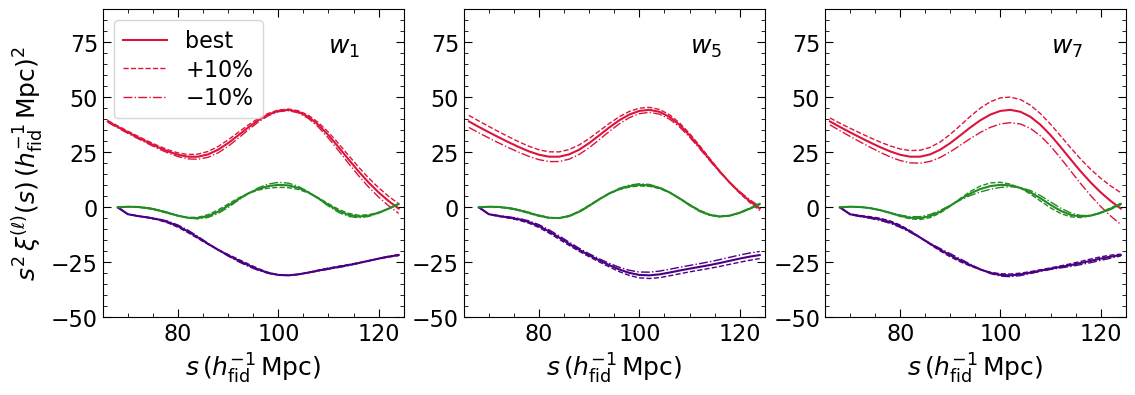

In [19]:
FSize = 4
fig,ax = plt.subplots(1,3,figsize=(3.3*FSize,FSize))

for c in range(3):
    ax[c].set_xlabel("$s\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$")
    if c==0:
        ax[c].set_ylabel("$s^{{2}}\\,\\xi^{{(\\ell)}}(s)\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
    ax[c].set_xlim(65,125)
    if Modify_Data:
        ax[c].set_ylim(-50,90)
    else:
        ax[c].set_ylim(-120,120)
    off = 1 if Modify_Data else 0
    offset = 1 if Include_Sig2Obs else 0
    ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_bestfit[offset],'-',
               c='crimson',label='best')
    ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_wm_plus[c][offset],'--',
               c='crimson',label='$+{0:.0f}\\%$'.format(perc_vary*100),lw=1)
    ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_wm_minus[c][offset],'-.',
               c='crimson',label='$-{0:.0f}\\%$'.format(perc_vary*100),lw=1)
    if L_Max > 1:
        ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+1],'-',c='indigo')
        ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_wm_plus[c][offset+1],'--',c='indigo',lw=1)
        ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_wm_minus[c][offset+1],'-.',c='indigo',lw=1)
        if L_Max == 3:
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+2],'-',c='forestgreen')
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_wm_plus[c][offset+2],'--',c='forestgreen',lw=1)
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_wm_minus[c][offset+2],'-.',c='forestgreen',lw=1)
    ax[c].text(110,70,'$w_{{{0:d}}}$'.format(w_idx[c]),fontsize=FS)
    if c==0:
        ax[c].legend(loc='upper left')
    ax[c].minorticks_on()
plt.show()

# w_m don't affect power spectrum multipole integral prediction

## Vary AP params
### $\Delta\alpha_{\rm iso},\Delta\alpha_{\rm AP}$

In [20]:
if tm.model_AP:
    # Daiso
    pred_Daiso_plus = tm.vary_prediction(ev_dict_bestfit,'Daiso',1,perc_vary,relative=False)
    pred_Daiso_minus = tm.vary_prediction(ev_dict_bestfit,'Daiso',-1,perc_vary,relative=False)

    # DaAP
    pred_DaAP_plus = tm.vary_prediction(ev_dict_bestfit,'DaAP',1,perc_vary,relative=False)
    pred_DaAP_minus = tm.vary_prediction(ev_dict_bestfit,'DaAP',-1,perc_vary,relative=False)

    pred_Da_plus = [pred_Daiso_plus,pred_DaAP_plus]
    pred_Da_minus = [pred_Daiso_minus,pred_DaAP_minus]

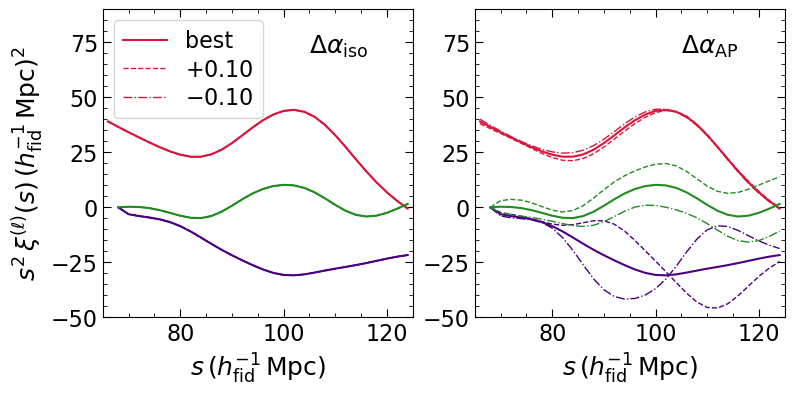

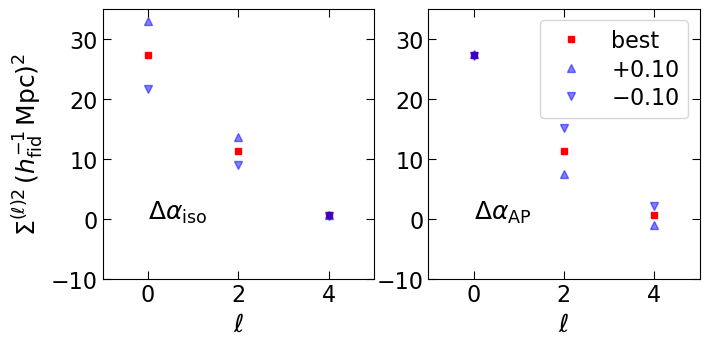

In [21]:
if tm.model_AP:
    Da_label = [tm.info['params']['Daiso']['latex'],tm.info['params']['DaAP']['latex']]
    FSize = 4
    fig,ax = plt.subplots(1,2,figsize=(2.2*FSize,FSize))
    
    for c in range(2):
        ax[c].set_xlabel("$s\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$")
        if c==0:
            ax[c].set_ylabel("$s^{{2}}\\,\\xi^{{(\\ell)}}(s)\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
        ax[c].set_xlim(65,125)
        if Modify_Data:
            ax[c].set_ylim(-50,90)
        else:
            ax[c].set_ylim(-120,120)
        off = 1 if Modify_Data else 0
        offset = 1 if Include_Sig2Obs else 0
        ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_bestfit[offset],'-',
                   c='crimson',label='best')
        ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_Da_plus[c][offset],'--',
                   c='crimson',label='$+{0:.2f}$'.format(perc_vary),lw=1)
        ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_Da_minus[c][offset],'-.',
                   c='crimson',label='$-{0:.2f}$'.format(perc_vary),lw=1)
        if L_Max > 1:
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+1],'-',c='indigo')
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_Da_plus[c][offset+1],'--',c='indigo',lw=1)
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_Da_minus[c][offset+1],'-.',c='indigo',lw=1)
            if L_Max == 3:
                ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+2],'-',c='forestgreen')
                ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_Da_plus[c][offset+2],'--',c='forestgreen',lw=1)
                ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_Da_minus[c][offset+2],'-.',c='forestgreen',lw=1)
        ax[c].text(105,70,'$'+Da_label[c]+'$',fontsize=FS)
        if c==0:
            ax[c].legend(loc='upper left')
        ax[c].minorticks_on()
    plt.show()
    
    if Include_Sig2Obs:
        Sigx = np.array([2*L for L in range(L_Max)])
    
        FSize = 3.5
        fig,ax = plt.subplots(1,2,figsize=(2.2*FSize,FSize))
    
        for c in range(2):
            ax[c].set_xlabel("$\\ell$")
            if c==0:
                ax[c].set_ylabel("$\\Sigma^{{(\\ell)2}} \\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
            ax[c].set_xlim(-1,2*L_Max-1)
            ax[c].set_ylim(-10,35)
            ax[c].set_xticks(Sigx)
            ax[c].plot(Sigx,pred_bestfit[0],'r',marker='s',
                       ls='none',markersize=4,label='best')
            ax[c].plot(Sigx,pred_Da_plus[c][0],'b',marker='^',
                       ls='none',markersize=6,label='$+{0:.2f}$'.format(perc_vary),alpha=0.5)
            ax[c].plot(Sigx,pred_Da_minus[c][0],'b',marker='v',
                       ls='none',markersize=6,label='$-{0:.2f}$'.format(perc_vary),alpha=0.5)
            ax[c].text(0,0,'$'+Da_label[c]+'$',fontsize=FS)
            if c==1:
                ax[c].legend(loc='upper right')
        plt.show()

## Vary $\sigma_{\rm v}$

In [22]:
# sigv
pred_sigv_plus = tm.vary_prediction(ev_dict_bestfit,'sigv',1,perc_vary)
pred_sigv_minus = tm.vary_prediction(ev_dict_bestfit,'sigv',-1,perc_vary)

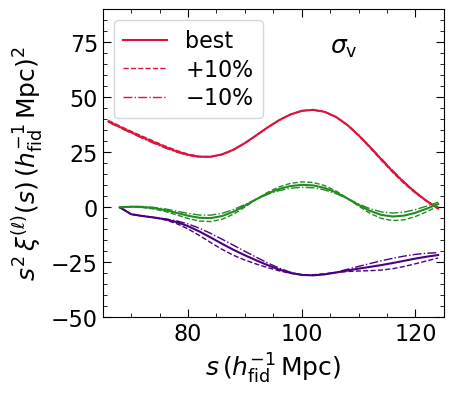

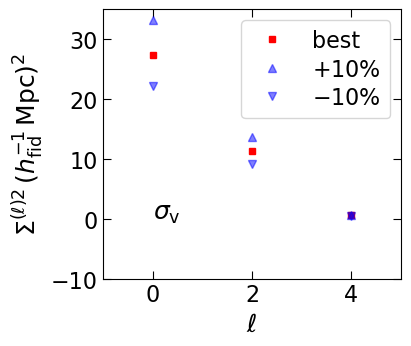

In [23]:
sigv_label = tm.info['params']['sigv']['latex'] 
FSize = 4
fig,ax = plt.subplots(1,1,figsize=(1.1*FSize,FSize))

ax.set_xlabel("$s\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$")
ax.set_ylabel("$s^{{2}}\\,\\xi^{{(\\ell)}}(s)\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
ax.set_xlim(65,125)
if Modify_Data:
    ax.set_ylim(-50,90)
else:
    ax.set_ylim(-120,120)
off = 1 if Modify_Data else 0
offset = 1 if Include_Sig2Obs else 0
ax.plot(tm.theory.svals,tm.theory.svals**2*pred_bestfit[offset],'-',
           c='crimson',label='best')
ax.plot(tm.theory.svals,tm.theory.svals**2*pred_sigv_plus[offset],'--',
           c='crimson',label='$+{0:.0f}\\%$'.format(perc_vary*100),lw=1)
ax.plot(tm.theory.svals,tm.theory.svals**2*pred_sigv_minus[offset],'-.',
           c='crimson',label='$-{0:.0f}\\%$'.format(perc_vary*100),lw=1)
if L_Max > 1:
    ax.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+1],'-',c='indigo')
    ax.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sigv_plus[offset+1],'--',c='indigo',lw=1)
    ax.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sigv_minus[offset+1],'-.',c='indigo',lw=1)
    if L_Max == 3:
        ax.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+2],'-',c='forestgreen')
        ax.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sigv_plus[offset+2],'--',c='forestgreen',lw=1)
        ax.plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sigv_minus[offset+2],'-.',c='forestgreen',lw=1)
ax.text(105,70,'$'+sigv_label+'$',fontsize=FS)
ax.legend(loc='upper left')
ax.minorticks_on()
plt.show()

if Include_Sig2Obs:
    Sigx = np.array([2*L for L in range(L_Max)])

    FSize = 3.5
    fig,ax = plt.subplots(1,1,figsize=(1.1*FSize,FSize))

    ax.set_xlabel("$\\ell$")
    ax.set_ylabel("$\\Sigma^{{(\\ell)2}} \\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
    ax.set_xlim(-1,2*L_Max-1)
    ax.set_ylim(-10,35)
    ax.set_xticks(Sigx)
    ax.plot(Sigx,pred_bestfit[0],'r',marker='s',
               ls='none',markersize=4,label='best')
    ax.plot(Sigx,pred_sigv_plus[0],'b',marker='^',
               ls='none',markersize=6,label='$+{0:.0f}\\%$'.format(perc_vary*100),alpha=0.5)
    ax.plot(Sigx,pred_sigv_minus[0],'b',marker='v',
               ls='none',markersize=6,label='$-{0:.0f}\\%$'.format(perc_vary*100),alpha=0.5)
    ax.text(0,0,'$'+sigv_label+'$',fontsize=FS)
    ax.legend(loc='upper right')
    plt.show()


## Vary $sdbmc$ params
### $B_{1\ast},B_{v\ast},\sigma,A_{\rm MC}$

In [24]:
# B1st
pred_B1st_plus = tm.vary_prediction(ev_dict_bestfit,'B1st',1,perc_vary)
pred_B1st_minus = tm.vary_prediction(ev_dict_bestfit,'B1st',-1,perc_vary)

# Bvst
pred_Bvst_plus = tm.vary_prediction(ev_dict_bestfit,'Bvst',1,perc_vary)
pred_Bvst_minus = tm.vary_prediction(ev_dict_bestfit,'Bvst',-1,perc_vary)

# sigma
pred_sigma_plus = tm.vary_prediction(ev_dict_bestfit,'sigma',1,perc_vary)
pred_sigma_minus = tm.vary_prediction(ev_dict_bestfit,'sigma',-1,perc_vary)

# AMC
pred_AMC_plus = tm.vary_prediction(ev_dict_bestfit,'AMC',1,perc_vary)
pred_AMC_minus = tm.vary_prediction(ev_dict_bestfit,'AMC',-1,perc_vary)

pred_sdbmc_plus = [pred_B1st_plus,pred_Bvst_plus,pred_sigma_plus,pred_AMC_plus]
pred_sdbmc_minus = [pred_B1st_minus,pred_Bvst_minus,pred_sigma_minus,pred_AMC_minus]


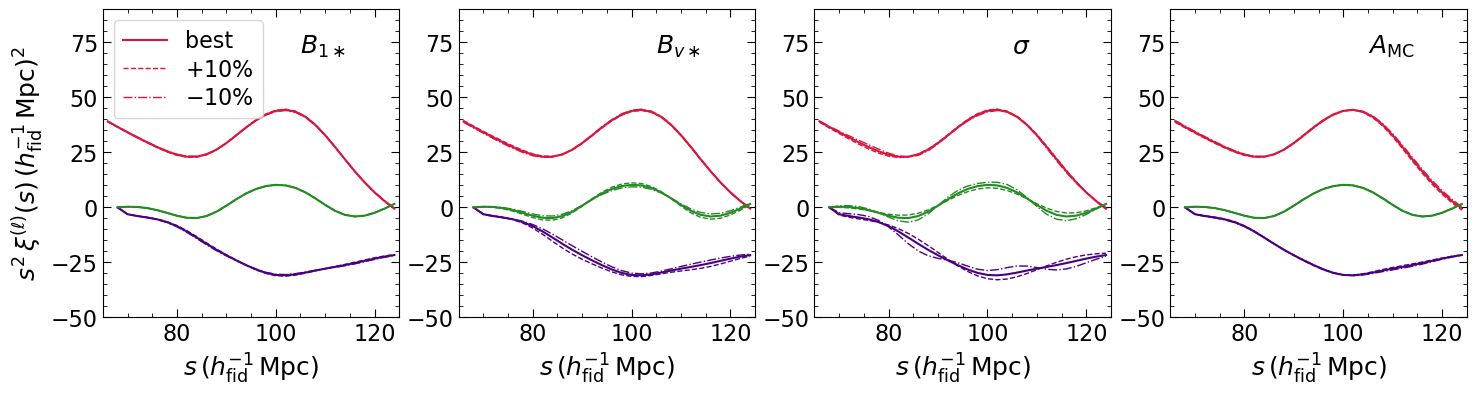

In [25]:
sdbmc_label = [tm.info['params'][key]['latex'] for key in ['B1st','Bvst','sigma','AMC']]
FSize = 4
fig,ax = plt.subplots(1,4,figsize=(4.4*FSize,FSize))

for c in range(4):
    ax[c].set_xlabel("$s\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})$")
    if c==0:
        ax[c].set_ylabel("$s^{{2}}\\,\\xi^{{(\\ell)}}(s)\\, (h^{{-1}}_{{\\rm fid}}\\,{{\\rm Mpc}})^{{2}}$")
    ax[c].set_xlim(65,125)
    if Modify_Data:
        ax[c].set_ylim(-50,90)
    else:
        ax[c].set_ylim(-120,120)
    off = 1 if Modify_Data else 0
    offset = 1 if Include_Sig2Obs else 0
    ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_bestfit[offset],'-',
               c='crimson',label='best')
    ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_sdbmc_plus[c][offset],'--',
               c='crimson',label='$+{0:.0f}\\%$'.format(perc_vary*100),lw=1)
    ax[c].plot(tm.theory.svals,tm.theory.svals**2*pred_sdbmc_minus[c][offset],'-.',
               c='crimson',label='$-{0:.0f}\\%$'.format(perc_vary*100),lw=1)
    if L_Max > 1:
        ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+1],'-',c='indigo')
        ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sdbmc_plus[c][offset+1],'--',c='indigo',lw=1)
        ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sdbmc_minus[c][offset+1],'-.',c='indigo',lw=1)
        if L_Max == 3:
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_bestfit[offset+2],'-',c='forestgreen')
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sdbmc_plus[c][offset+2],'--',c='forestgreen',lw=1)
            ax[c].plot(tm.theory.svals[off:],tm.theory.svals[off:]**2*pred_sdbmc_minus[c][offset+2],'-.',c='forestgreen',lw=1)
    ax[c].text(105,70,'$'+sdbmc_label[c]+'$',fontsize=FS)
    if c==0:
        ax[c].legend(loc='upper left')
    ax[c].minorticks_on()
plt.show()

# sdbmc params don't affect power spectrum multipole integral prediction